# 01 — Data Exploration & Preprocessing

## AT&T Spam Detector

### Objective

This notebook explores and prepares the SMS dataset used to build a deep-learning spam classifier.

The main objectives are to:

- inspect the raw dataset and assess its quality;
- analyze the target distribution and characteristics of SMS messages;
- identify appropriate text-preprocessing decisions;
- create reproducible train, validation, and test sets;
- transform unstructured SMS text into numerical representations suitable for neural networks;
- explicitly demonstrate the transformation from raw text to model-ready tensors.

Model training will be performed in subsequent notebooks.

In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Alex\AppData\Local\Programs\Python\Python312\python.exe
3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]


In [2]:
# Imports and reproducibility
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


NumPy version: 2.5.2
Pandas version: 3.0.5


In [3]:
# Project-path

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

DATA_PATH = RAW_DATA_DIR / "spam.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Dataset path: {DATA_PATH}")

Project root: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\4_Att-spam-detector
Raw data directory: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\4_Att-spam-detector\data\raw
Dataset path: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\4_Att-spam-detector\data\raw\spam.csv


## 1. Load and inspect the raw dataset

The raw SMS dataset is stored locally in `data/raw/`.

At this stage, the objective is to inspect the dataset structure and identify potential data-quality issues before making any preprocessing decisions.

In [4]:
# Verify that the dataset is available

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset exists: {DATA_PATH.exists()}")

Dataset path: c:\Users\Alex\Desktop\Jehda AI\Fullstack\CDSD Certification\4_Att-spam-detector\data\raw\spam.csv
Dataset exists: True


In [5]:
# Load the raw dataset

df_raw = pd.read_csv(DATA_PATH, encoding="latin-1")

print(f"Dataset shape: {df_raw.shape}")

df_raw.head()

Dataset shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
# Inspect the raw dataset structure

print("Columns:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values:")
print(df_raw.isna().sum())

Columns:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data types:
v1            str
v2            str
Unnamed: 2    str
Unnamed: 3    str
Unnamed: 4    str
dtype: object

Missing values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


### 1.1 Investigate unexpected columns

The raw dataset contains three additional columns (`Unnamed: 2`, `Unnamed: 3`, and `Unnamed: 4`) that are almost entirely missing.

Before removing them, we inspect their non-null values to determine whether they contain meaningful information or are artifacts of the source CSV structure.

In [7]:
# Inspect non-null values in the unexpected columns

extra_columns = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]

for column in extra_columns:
    non_null_values = df_raw.loc[df_raw[column].notna(), ["v1", "v2", column]]

    print(f"\n{column}")
    print(f"Non-null values: {len(non_null_values)}")
    display(non_null_values)


Unnamed: 2
Non-null values: 50


,v1,v2,Unnamed: 2
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249
281,ham,\Wen u miss someone,the person is definitely special for u..... B...
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ..."
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence.."""
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D"""
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@"""



Unnamed: 3
Non-null values: 12


,v1,v2,Unnamed: 3
95,spam,Your free ringtone is waiting to be collected....,"MK17 92H. 450Ppw 16"""
281,ham,\Wen u miss someone,why to miss them
899,spam,Your free ringtone is waiting to be collected....,"MK17 92H. 450Ppw 16"""
1038,ham,"Edison has rightly said, \A fool can ask more ...",GE
2170,ham,\CAN I PLEASE COME UP NOW IMIN TOWN.DONTMATTER...,"U NO THECD ISV.IMPORTANT TOME 4 2MORO\"""""
2255,ham,I just lov this line: \Hurt me with the truth,i wil tolerat.bcs ur my someone..... But
3145,ham,\SHIT BABE.. THASA BIT MESSED UP.YEH,"ILLSPEAK 2 U2MORO WEN IM NOT ASLEEP...\"""""
3506,ham,Two fundamentals of cool life: \Walk,"whoever is the KING\""!... Gud nyt"""
3525,ham,\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...,TX 4 FONIN HON
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...","\""OH No! COMPETITION\"". Who knew"



Unnamed: 4
Non-null values: 6


,v1,v2,Unnamed: 4
281,ham,\Wen u miss someone,"just Keep-in-touch\"" gdeve.."""
1038,ham,"Edison has rightly said, \A fool can ask more ...","GNT:-)"""
2255,ham,I just lov this line: \Hurt me with the truth,"Never comfort me with a lie\"" gud ni8 and swe..."
3525,ham,\HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE...,"CALL 2MWEN IM BK FRMCLOUD 9! J X\"""""
4668,ham,"When I was born, GOD said, \Oh No! Another IDI...","one day these two will become FREINDS FOREVER!"""
5048,ham,"Edison has rightly said, \A fool can ask more ...","GNT:-)"""


In [8]:
# Inspect target labels

print("Target values:")
print(df_raw["v1"].value_counts(dropna=False))

Target values:
v1
ham     4825
spam     747
Name: count, dtype: int64


### 1.2 Reconstruct the SMS text

The dataset contains 5,572 observations. The target column `v1` contains the expected binary labels (`ham` and `spam`), while `v2` contains the main SMS text.

Inspection of the three additional `Unnamed` columns shows that they are not separate predictive features. For a small number of observations, they contain fragments of the original SMS message that were split across multiple CSV fields.

Therefore, simply dropping these columns would discard genuine message content. We reconstruct the complete SMS text by combining all available text fragments for each observation, while preserving the original raw dataframe unchanged.

In [9]:
# Create a clean working dataframe while preserving df_raw

text_columns = ["v2", "Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]

df = pd.DataFrame({
    "label": df_raw["v1"],
    "text": df_raw[text_columns]
        .fillna("")
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
})

print(f"Working dataset shape: {df.shape}")

df.head()

Working dataset shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Quality check 1. Compare reconstructed messages with the original fragmented records

fragmented_mask = df_raw[
    ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]
].notna().any(axis=1)

print(f"Messages requiring reconstruction: {fragmented_mask.sum()}")

display(
    pd.DataFrame({
        "original_v2": df_raw.loc[fragmented_mask, "v2"],
        "reconstructed_text": df.loc[fragmented_mask, "text"]
    }).head(10)
)

Messages requiring reconstruction: 50


,original_v2,reconstructed_text
95,Your free ringtone is waiting to be collected....,Your free ringtone is waiting to be collected....
281,\Wen u miss someone,\Wen u miss someone the person is definitely s...
444,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...
671,SMS. ac sun0819 posts HELLO:\You seem cool,SMS. ac sun0819 posts HELLO:\You seem cool wan...
710,Height of Confidence: All the Aeronautics prof...,Height of Confidence: All the Aeronautics prof...
899,Your free ringtone is waiting to be collected....,Your free ringtone is waiting to be collected....
1038,"Edison has rightly said, \A fool can ask more ...","Edison has rightly said, \A fool can ask more ..."
1127,"Height of \Oh shit....!!\"" situation: A guy th...","Height of \Oh shit....!!\"" situation: A guy th..."
1266,\Hey sorry I didntgive ya a a bellearlier hunny,\Hey sorry I didntgive ya a a bellearlier hunn...
1384,"Storming msg: Wen u lift d phne, u say \HELLO\...","Storming msg: Wen u lift d phne, u say \HELLO\..."


In [11]:
# Quality chek 2.Validate labels and reconstructed text

print("Missing values:")
print(df.isna().sum())

print("\nEmpty messages:")
print(df["text"].str.strip().eq("").sum())

print("\nTarget distribution:")
print(df["label"].value_counts())

print("\nTarget proportions:")
print(df["label"].value_counts(normalize=True).round(4))

Missing values:
label    0
text     0
dtype: int64

Empty messages:
0

Target distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Target proportions:
label
ham     0.8659
spam    0.1341
Name: proportion, dtype: float64


### 1.3 Duplicate analysis

Duplicate SMS messages require particular attention before creating the train, validation, and test sets.

If identical messages occur in multiple dataset splits, a model could encounter the same text during training and evaluation. This would introduce data leakage and could lead to an overly optimistic estimate of generalization performance.

We therefore inspect exact duplicates before deciding how they should be handled.

In [12]:
# Check exact duplicate rows

duplicate_rows = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_rows}")
print(
    f"Unique label-text combinations: "
    f"{df.drop_duplicates().shape[0]}"
)

Exact duplicate rows: 414
Unique label-text combinations: 5158


In [13]:
# Check duplicated SMS text independently of the label

duplicate_texts = df["text"].duplicated().sum()
unique_texts = df["text"].nunique()

print(f"Duplicated text occurrences: {duplicate_texts}")
print(f"Unique SMS texts: {unique_texts}")

Duplicated text occurrences: 414
Unique SMS texts: 5158


In [14]:
# Check whether identical SMS texts have conflicting labels

labels_per_text = df.groupby("text")["label"].nunique()

conflicting_texts = labels_per_text[labels_per_text > 1]

print(
    f"SMS texts associated with multiple labels: "
    f"{len(conflicting_texts)}"
)

SMS texts associated with multiple labels: 0


In [15]:
# Inspect the most frequently repeated SMS texts

text_frequency = (
    df.groupby(["text", "label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(text_frequency.head(15))

,text,label,count
3652,"Sorry, I'll call later",ham,30
1747,I cant pick the phone right now. Pls send a me...,ham,12
3148,Ok...,ham,10
86,7 wonders in My WORLD 7th You 6th Ur style 5th...,ham,4
3051,Ok,ham,4
3128,Ok.,ham,4
3176,Okie,ham,4
3284,Please call our customer service representativ...,spam,4
3456,"Say this slowly.? GOD,I LOVE YOU &amp; I NEED ...",ham,4
4391,"Wen ur lovable bcums angry wid u, dnt take it ...",ham,4


### 1.4 Remove exact duplicate SMS messages

The dataset contains 414 duplicate SMS occurrences, reducing the 5,572 raw observations to 5,158 unique SMS texts.

No identical SMS text is associated with conflicting class labels.

Although repeated messages may represent genuine repetitions in real-world SMS traffic, retaining identical messages during a random train/validation/test split could place the same text in multiple subsets. This would introduce information leakage and potentially produce an overly optimistic estimate of model generalization.

For this experimental classification dataset, exact duplicate messages are therefore removed **before data splitting**. The resulting evaluation will measure the model's ability to classify previously unseen SMS texts rather than memorized duplicates.

In [16]:
# Remove exact duplicate SMS messages

rows_before = len(df)

df = (
    df.drop_duplicates(subset="text")
    .reset_index(drop=True)
)

rows_after = len(df)
rows_removed = rows_before - rows_after

print(f"Rows before deduplication: {rows_before}")
print(f"Rows after deduplication: {rows_after}")
print(f"Duplicate rows removed: {rows_removed}")

Rows before deduplication: 5572
Rows after deduplication: 5158
Duplicate rows removed: 414


In [17]:
# Validate the deduplicated dataset

print(f"Dataset shape: {df.shape}")
print(f"Remaining duplicated texts: {df['text'].duplicated().sum()}")

print("\nMissing values:")
print(df.isna().sum())

print("\nEmpty messages:")
print(df["text"].str.strip().eq("").sum())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass proportions:")
print(df["label"].value_counts(normalize=True).round(4))

Dataset shape: (5158, 2)
Remaining duplicated texts: 0

Missing values:
label    0
text     0
dtype: int64

Empty messages:
0

Class distribution:
label
ham     4516
spam     642
Name: count, dtype: int64

Class proportions:
label
ham     0.8755
spam    0.1245
Name: proportion, dtype: float64


### 1.5 SMS length analysis

Before tokenization, we examine the distribution of SMS lengths.

Message length may differ between ham and spam messages and can help inform later preprocessing decisions, particularly the choice of maximum sequence length for padding and truncation.

At this stage, length statistics are calculated from the reconstructed but otherwise unprocessed SMS text.

In [18]:
# Calculate basic message-length features for exploration

df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

df[["text", "label", "char_count", "word_count"]].head()

,text,label,char_count,word_count
0,"Go until jurong point, crazy.. Available only ...",ham,111,20
1,Ok lar... Joking wif u oni...,ham,29,6
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,155,28
3,U dun say so early hor... U c already then say...,ham,49,11
4,"Nah I don't think he goes to usf, he lives aro...",ham,61,13


In [19]:
# Overall SMS length statistics

print("Character-count statistics:")
display(df["char_count"].describe())

print("\nWord-count statistics:")
display(df["word_count"].describe())

Character-count statistics:


count    5158.000000
mean       79.259403
std        58.338914
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: char_count, dtype: float64


Word-count statistics:


count    5158.000000
mean       15.418961
std        11.111992
min         1.000000
25%         7.000000
50%        12.000000
75%        22.000000
max       171.000000
Name: word_count, dtype: float64

In [20]:
# SMS length statistics by class

length_by_class = (
    df.groupby("label")[["char_count", "word_count"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

display(length_by_class)

char_count                        word_count                       
            mean median    std min  max       mean median    std min  max
label                                                                    
ham        70.93   53.0  56.58   2  910      14.24   11.0  11.17   1  171
spam      137.87  148.5  30.07  13  224      23.70   25.0   5.97   2   35

In [21]:
# Inspect message-length percentiles

percentiles = [0.50, 0.75, 0.90, 0.95, 0.99]

length_percentiles = df["word_count"].quantile(percentiles)

print("Word-count percentiles:")
print(length_percentiles)

Word-count percentiles:
0.50    12.0
0.75    22.0
0.90    29.0
0.95    33.0
0.99    50.0
Name: word_count, dtype: float64


### 1.6 Visualize SMS length distributions

The descriptive statistics suggest that spam messages tend to be longer than ham messages, while a small number of unusually long messages create a long tail in the overall distribution.

We visualize message lengths by class to better understand this pattern and to support later sequence-length decisions.

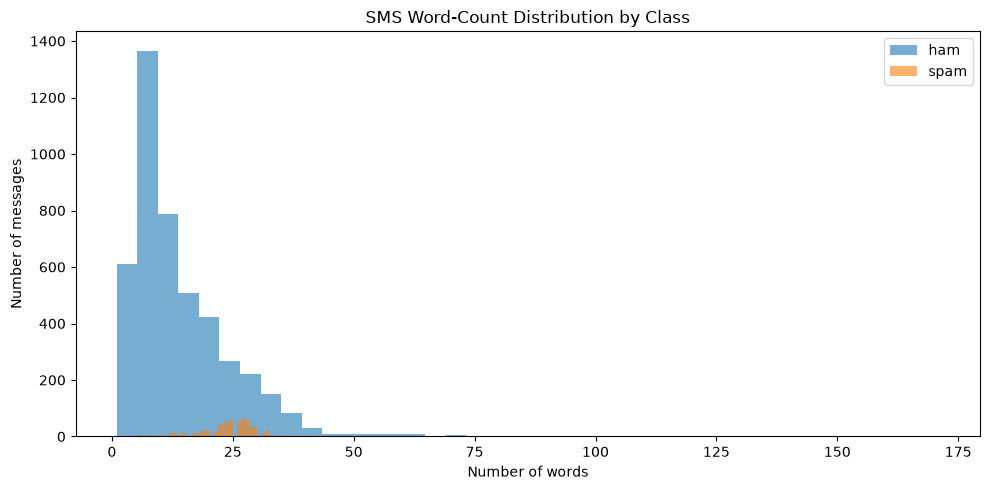

In [22]:
import matplotlib.pyplot as plt
# Compare word-count distributions by class

plt.figure(figsize=(10, 5))

for label in ["ham", "spam"]:
    subset = df.loc[df["label"] == label, "word_count"]

    plt.hist(
        subset,
        bins=40,
        alpha=0.6,
        label=label,
    )

plt.xlabel("Number of words")
plt.ylabel("Number of messages")
plt.title("SMS Word-Count Distribution by Class")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Inspect the longest SMS messages

longest_messages = (
    df[
        ["label", "text", "char_count", "word_count"]
    ]
    .sort_values("word_count", ascending=False)
    .head(10)
)

display(longest_messages)

,label,text,char_count,word_count
1057,ham,For me the love should start with attraction.i...,910,171
1798,ham,The last thing i ever wanted to do was hurt yo...,790,162
2072,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2329,ham,Indians r poor but India is not a poor country...,622,109
1526,ham,How to Make a girl Happy? It's not at all diff...,593,103
2277,ham,"Good evening Sir, hope you are having a nice d...",481,98
2267,ham,A Boy loved a gal. He propsd bt she didnt mind...,450,96
1461,ham,"Hey sweet, I was wondering when you had a mome...",458,95
1932,ham,I can't keep going through this. It was never ...,431,89
4564,ham,"no, i *didn't* mean to post it. I wrote it, an...",415,88


In [24]:
# Quantify the long tail of the word-count distribution

for threshold in [30, 40, 50, 75, 100]:
    count = (df["word_count"] > threshold).sum()
    proportion = count / len(df)

    print(
        f"Messages > {threshold:3d} words: "
        f"{count:4d} ({proportion:.2%})"
    )

Messages >  30 words:  375 (7.27%)
Messages >  40 words:   91 (1.76%)
Messages >  50 words:   51 (0.99%)
Messages >  75 words:   15 (0.29%)
Messages > 100 words:    5 (0.10%)


### 1.7 Inspect text characteristics

Text preprocessing should preserve information that may be useful for spam detection.

Unlike some NLP tasks, aggressive cleaning is not automatically desirable here. Numbers, URLs, currency symbols, punctuation, capitalization, and other formatting patterns may themselves carry useful spam-related information.

Before defining the preprocessing pipeline, we therefore inspect several basic text characteristics by class.

In [25]:
# Create exploratory text-characteristic indicators

df["has_url"] = df["text"].str.contains(
    r"http|www\.",
    case=False,
    regex=True,
)

df["has_digit"] = df["text"].str.contains(
    r"\d",
    regex=True,
)

df["has_currency"] = df["text"].str.contains(
    r"[£$€]",
    regex=True,
)

df["has_exclamation"] = df["text"].str.contains(
    "!",
    regex=False,
)

df["uppercase_count"] = df["text"].str.count(r"[A-Z]")

In [26]:
# Compare text characteristics between ham and spam

binary_features = [
    "has_url",
    "has_digit",
    "has_currency",
    "has_exclamation",
]

characteristics_by_class = (
    df.groupby("label")[binary_features]
    .mean()
    .mul(100)
    .round(2)
)

display(characteristics_by_class)

,has_url,has_digit,has_currency,has_exclamation
label,,,,
ham,0.02,15.83,0.42,11.74
spam,13.86,93.93,33.33,47.04


In [27]:
# Compare uppercase-character usage by class

uppercase_by_class = (
    df.groupby("label")["uppercase_count"]
    .agg(["mean", "median", "max"])
    .round(2)
)

display(uppercase_by_class)

,mean,median,max
label,,,
ham,3.97,2.0,129
spam,15.15,13.0,128


In [28]:
# Inspect representative spam messages

display(
    df.loc[
        df["label"] == "spam",
        [
            "text",
            "has_url",
            "has_digit",
            "has_currency",
            "has_exclamation",
        ],
    ].head(15)
)

,text,has_url,has_digit,has_currency,has_exclamation
2,Free entry in 2 a wkly comp to win FA Cup fina...,False,True,False,False
5,FreeMsg Hey there darling it's been 3 week's n...,False,True,True,True
8,WINNER!! As a valued network customer you have...,False,True,True,True
9,Had your mobile 11 months or more? U R entitle...,False,True,False,True
11,"SIX chances to win CASH! From 100 to 20,000 po...",False,True,False,True
12,URGENT! You have won a 1 week FREE membership ...,True,True,True,True
15,"XXXMobileMovieClub: To use your credit, click ...",True,False,False,False
19,England v Macedonia - dont miss the goals/team...,False,True,False,False
34,Thanks for your subscription to Ringtone UK yo...,False,True,True,False
42,07732584351 - Rodger Burns - MSG = We tried to...,False,True,False,False


In [ ]:
"""
The differences are substantial:

Characteristic	            Ham	    Spam
Contains URL pattern	    0.02%	13.86%
Contains digit	            15.83%	93.93%
Contains currency symbol	0.42%	33.33%
Contains !	                11.74%	47.04%
Mean uppercase characters	3.97	15.15
Median uppercase characters	2	13
"""


### Preprocessing decision: preserve potentially informative text signals

Exploratory analysis shows substantial differences between ham and spam messages in several textual characteristics.

Spam messages are considerably more likely to contain digits, currency symbols, exclamation marks, URLs, and uppercase characters. These patterns may carry useful information for spam classification.

For this reason, aggressive text cleaning will be avoided. In particular, punctuation, numbers, currency symbols, and other potentially informative patterns will not be removed mechanically.

The preprocessing pipeline will instead remain deliberately conservative. Tokenization and normalization choices will depend on the representation required by each neural-network architecture.

The exploratory variables created above are used to understand the dataset and are not, at this stage, separate inputs to the neural network.

### 1.8 Target distribution and class imbalance

The target distribution is examined before splitting the dataset.

Class imbalance is important for both training and evaluation. A model that predominantly predicts the majority class could achieve relatively high accuracy while performing poorly at detecting spam.

Therefore, accuracy alone will not be sufficient to evaluate model performance.

In [29]:
# Summarize target distribution

class_counts = df["label"].value_counts()
class_proportions = df["label"].value_counts(normalize=True)

class_summary = pd.DataFrame({
    "count": class_counts,
    "proportion": class_proportions,
    "percentage": class_proportions * 100,
})

class_summary["percentage"] = class_summary["percentage"].round(2)

display(class_summary)

,count,proportion,percentage
label,,,
ham,4516,0.875533,87.55
spam,642,0.124467,12.45


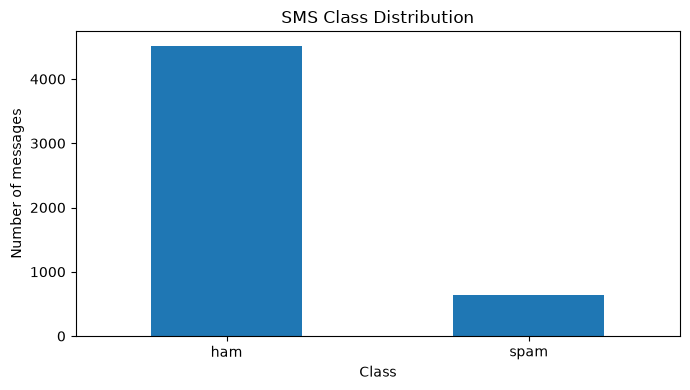

In [30]:
# Visualize class distribution

class_counts.plot(
    kind="bar",
    figsize=(7, 4),
)

plt.title("SMS Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of messages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
# Calculate majority-to-minority class ratio

ham_count = class_counts["ham"]
spam_count = class_counts["spam"]

imbalance_ratio = ham_count / spam_count

print(f"Ham messages: {ham_count}")
print(f"Spam messages: {spam_count}")
print(f"Ham-to-spam ratio: {imbalance_ratio:.2f}:1")

Ham messages: 4516
Spam messages: 642
Ham-to-spam ratio: 7.03:1


In [ ]:
"""We split before fitting any vocabulary, tokenizer, normalization statistics, 
or model-related transformation. The test set must remain untouched until final evaluation."""

### 1.9 Train / validation / test split

The deduplicated dataset is divided into training, validation, and test sets using a 70% / 15% / 15% split.

Because the target is imbalanced, stratified sampling is used so that the proportion of ham and spam messages remains approximately consistent across all three subsets.

The split is performed **before fitting any tokenizer, vocabulary, or other data-dependent preprocessing step**. This prevents information from the validation or test sets from influencing the learned text representation.

The test set will remain untouched during model development and will only be used for final model evaluation.

In [32]:
# First split: 70% training, 30% temporary set

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

# Second split: divide temporary set equally
# -> 15% validation, 15% test

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"],
)

# Reset indices for clean downstream processing
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [33]:
# Check split sizes

print(f"Full dataset: {len(df)}")
print(f"Training set: {len(train_df)} ({len(train_df) / len(df):.2%})")
print(f"Validation set: {len(val_df)} ({len(val_df) / len(df):.2%})")
print(f"Test set: {len(test_df)} ({len(test_df) / len(df):.2%})")

assert len(train_df) + len(val_df) + len(test_df) == len(df)

Full dataset: 5158
Training set: 3610 (69.99%)
Validation set: 774 (15.01%)
Test set: 774 (15.01%)


In [34]:
# Validate stratification
def class_distribution(dataframe):
    return (
        dataframe["label"]
        .value_counts(normalize=True)
        .rename("proportion")
        .round(4)
    )

split_distribution = pd.concat(
    {
        "train": class_distribution(train_df),
        "validation": class_distribution(val_df),
        "test": class_distribution(test_df),
    },
    axis=1,
)

display(split_distribution)

,train,validation,test
label,,,
ham,0.8756,0.8747,0.876
spam,0.1244,0.1253,0.124


In [35]:
# Because we deduplicated before splitting, 
# identical SMS texts should not cross subset boundaries. Let's verify it explicitly:

train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

train_val_overlap = train_texts.intersection(val_texts)
train_test_overlap = train_texts.intersection(test_texts)
val_test_overlap = val_texts.intersection(test_texts)

print(f"Train/validation text overlap: {len(train_val_overlap)}")
print(f"Train/test text overlap: {len(train_test_overlap)}")
print(f"Validation/test text overlap: {len(val_test_overlap)}")

Train/validation text overlap: 0
Train/test text overlap: 0
Validation/test text overlap: 0


### 1.10 Define model inputs and target

The exploratory variables created during EDA describe characteristics of the messages but are not used as separate model features.

The neural-network models will receive the SMS text as their input. The target labels are converted from categorical strings (`ham` / `spam`) to binary numerical values:

- `ham` → 0
- `spam` → 1

This convention makes spam the positive class, which will later make precision, recall, F1-score, and false-negative interpretation more intuitive.

In [36]:
# Extract text and target from each split

X_train = train_df["text"].copy()
X_val = val_df["text"].copy()
X_test = test_df["text"].copy()

y_train = train_df["label"].map({
    "ham": 0,
    "spam": 1,
})

y_val = val_df["label"].map({
    "ham": 0,
    "spam": 1,
})

y_test = test_df["label"].map({
    "ham": 0,
    "spam": 1,
})

In [37]:
# Validate the mapping
# We should see only labels 0 and 1, with no missing values.

print("Training text shape:", X_train.shape)
print("Training target shape:", y_train.shape)

print("\nEncoded training labels:")
print(y_train.value_counts().sort_index())

print("\nEncoded validation labels:")
print(y_val.value_counts().sort_index())

print("\nEncoded test labels:")
print(y_test.value_counts().sort_index())

print("\nMissing encoded labels:")
print(
    "train:", y_train.isna().sum(),
    "| validation:", y_val.isna().sum(),
    "| test:", y_test.isna().sum(),
)

Training text shape: (3610,)
Training target shape: (3610,)

Encoded training labels:
label
0    3161
1     449
Name: count, dtype: int64

Encoded validation labels:
label
0    677
1     97
Name: count, dtype: int64

Encoded test labels:
label
0    678
1     96
Name: count, dtype: int64

Missing encoded labels:
train: 0 | validation: 0 | test: 0


In [38]:
# Inspect representative model inputs and targets

for i in range(5):
    print(f"Example {i + 1}")
    print(f"Text:   {X_train.iloc[i]}")
    print(f"Label:  {y_train.iloc[i]}")
    print("-" * 80)

Example 1
Text:   I also thk too fast... Xy suggest one not me. U dun wan it's ok. Going 2 rain leh where got gd.
Label:  0
--------------------------------------------------------------------------------
Example 2
Text:   Ok good then i later come find Ì_... C lucky i told Ì_ to go earlier... Later pple take finish Ì_ no more again...
Label:  0
--------------------------------------------------------------------------------
Example 3
Text:   It's wylie, you in tampa or sarasota?
Label:  0
--------------------------------------------------------------------------------
Example 4
Text:   WHEN THE FIRST STRIKE IS A RED ONE. THE BIRD + ANTELOPE BEGIN TOPLAY IN THE FIELDOF SELFINDEPENDENCE BELIEVE THIS + THE FLOWER OF CONTENTION WILL GROW.RANDOM!
Label:  0
--------------------------------------------------------------------------------
Example 5
Text:   Good evening Sir, Al Salam Wahleykkum.sharing a happy news.By the grace of God, i got an offer from Tayseer,TISSCO and i joined.Hope you a

### 1.11 Inspect unusual characters and encoding artifacts

The sample messages contain several unusual non-ASCII character sequences.

Before tokenization, these characters are inspected to determine whether they represent genuine message content or encoding artifacts. They are not removed automatically, since unnecessary character deletion could alter the original SMS content and discard potentially useful information.

In [39]:
# Identify messages containing non-ASCII characters

non_ascii_mask = df["text"].str.contains(
    r"[^\x00-\x7F]",
    regex=True
)

print(f"Messages containing non-ASCII characters: {non_ascii_mask.sum()}")
print(
    f"Proportion of dataset: "
    f"{non_ascii_mask.mean():.2%}"
)

display(
    df.loc[
        non_ascii_mask,
        ["label", "text"]
    ].head(20)
)

Messages containing non-ASCII characters: 440
Proportion of dataset: 8.53%


,label,text
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
12,spam,URGENT! You have won a 1 week FREE membership ...
18,ham,Fine if thatåÕs the way u feel. ThatåÕs the wa...
19,spam,England v Macedonia - dont miss the goals/team...
21,ham,IÛ÷m going to try for 2 months ha ha only joking
22,ham,So Ì_ pay first lar... Then when is da stock c...
34,spam,Thanks for your subscription to Ringtone UK yo...
35,ham,Yup... Ok i go home look at the timings then i...
65,spam,"As a valued customer, I am pleased to advise y..."


In [40]:
# Inspect messages containing the suspicious 'Ì' character

suspicious_mask = df["text"].str.contains(
    "Ì",
    regex=False,
    na=False
)

print(
    f"Messages containing 'Ì': "
    f"{suspicious_mask.sum()}"
)

display(
    df.loc[
        suspicious_mask,
        ["label", "text"]
    ].head(20)
)

Messages containing 'Ì': 140


,label,text
19,spam,England v Macedonia - dont miss the goals/team...
22,ham,So Ì_ pay first lar... Then when is da stock c...
35,ham,Yup... Ok i go home look at the timings then i...
123,ham,ÌÏ predict wat time Ì_'ll finish buying?
138,ham,Got c... I lazy to type... I forgot Ì_ in lect...
203,ham,ÌÏ say until like dat i dun buy ericsson oso c...
210,ham,Yup... How Ì_ noe leh...
421,ham,7 at esplanade.. Do Ì_ mind giving me a lift c...
492,ham,When can Ì_ come out?
566,ham,ÌÏ wait 4 me in sch i finish ard 5..


In [41]:
# Which non-ASCII characters occur most frequently?

from collections import Counter

non_ascii_chars = Counter(
    char
    for text in df["text"]
    for char in text
    if ord(char) > 127
)

print("Most common non-ASCII characters:")
for char, count in non_ascii_chars.most_common(20):
    print(repr(char), count)

Most common non-ASCII characters:
'å' 321
'£' 268
'Ì' 180
'\x89' 69
'Û' 69
'Ï' 55
'Õ' 39
'÷' 37
'Ò' 11
'Ó' 6
'ª' 3
'Ð' 3
'©' 3
'¬' 2
'Ô' 2
'Á' 2
'¼' 1
'È' 1
'ä' 1
'Â' 1


#### 1.12 Encoding inspection conclusion

Approximately 8.5% of the messages contain at least one non-ASCII character. The inspection shows a mixture of potentially meaningful symbols, such as the pound sign (`£`), and apparent encoding artifacts such as `Ì`, `Û`, and related characters.

Because some non-ASCII symbols may carry useful information for spam detection, blanket removal of non-ASCII characters would unnecessarily discard signal.

At the same time, manually replacing suspected encoding artifacts would require assumptions about their intended original characters and could introduce preprocessing errors.

The reconstructed SMS text is therefore preserved without speculative character-level correction. The subsequent tokenizer will handle the observed text consistently, while the preprocessing pipeline remains reproducible and minimally destructive.

In [ ]:
""""Status:

Raw spam.csv
      ↓
Repair fragmented CSV message fields
      ↓
Unique reconstructed SMS text
      ↓
Train / validation / test split
      ↓
X = SMS text
y = binary target
      ↓
NEXT: tokenizer / vocabulary
      ↓
numerical sequences
      ↓
padded tensors
      ↓
neural network
      ↓
spam probability

"""

In [42]:
try:
    import tensorflow as tf
    print(f"TensorFlow version: {tf.__version__}")
except ImportError:
    print("TensorFlow is not installed in the current notebook environment.")

TensorFlow version: 2.21.0


### 1.13 Training vocabulary with TextVectorization

The SMS text must be transformed from unstructured strings into numerical sequences before it can be processed by a neural network.

For the baseline deep-learning models, Keras `TextVectorization` is used to learn a vocabulary and map tokens to integer indices.

To prevent data leakage, the vectorizer is adapted **only on the training text**. Validation and test messages therefore have no influence on the learned vocabulary.

At this stage, the vectorizer is first used to inspect the vocabulary and token-length distribution. The final sequence length will be selected from the training data rather than chosen arbitrarily.

In [43]:
# Temporary vectorizer used to inspect tokenized training sequences

from tensorflow.keras.layers import TextVectorization

inspection_vectorizer = TextVectorization(
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
)

inspection_vectorizer.adapt(X_train)

In [44]:
# Inspect the learned vocabulary

vocabulary = inspection_vectorizer.get_vocabulary()

print(f"Vocabulary size: {len(vocabulary)}")
print("\nFirst 30 vocabulary entries:")
print(vocabulary[:30])

Vocabulary size: 7648

First 30 vocabulary entries:
['', '[UNK]', np.str_('to'), np.str_('i'), np.str_('you'), np.str_('a'), np.str_('the'), np.str_('u'), np.str_('and'), np.str_('is'), np.str_('in'), np.str_('me'), np.str_('my'), np.str_('for'), np.str_('your'), np.str_('it'), np.str_('have'), np.str_('of'), np.str_('that'), np.str_('call'), np.str_('on'), np.str_('are'), np.str_('2'), np.str_('im'), np.str_('so'), np.str_('now'), np.str_('not'), np.str_('but'), np.str_('or'), np.str_('at')]


In [45]:
# Demonstrate text-to-integer transformation

sample_texts = X_train.iloc[:5]

sample_sequences = inspection_vectorizer(sample_texts)

for text, sequence in zip(sample_texts, sample_sequences):
    print("RAW SMS:")
    print(text)

    print("\nINTEGER SEQUENCE:")
    print(sequence.numpy())

    print("-" * 80)

RAW SMS:
I also thk too fast... Xy suggest one not me. U dun wan it's ok. Going 2 rain leh where got gd.

INTEGER SEQUENCE:
[   3  163  238  119  720 1002 1662   78   26   11    7  212  207   43
   45   70   22 1190  374  131   55  598    0    0    0    0    0    0
    0    0]
--------------------------------------------------------------------------------
RAW SMS:
Ok good then i later come find Ì_... C lucky i told Ì_ to go earlier... Later pple take finish Ì_ no more again...

INTEGER SEQUENCE:
[  45   61   60    3  127   62  170  117  155  593    3  233  117    2
   46  971  127 2348   96  257  117   42  116  205    0    0    0    0
    0    0]
--------------------------------------------------------------------------------
RAW SMS:
It's wylie, you in tampa or sarasota?

INTEGER SEQUENCE:
[  43 1601    4   10  830   28 2265    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
-------------------------------------------

### 1.14 Tokenized sequence-length analysis

The earlier message-length analysis used whitespace-separated word counts. However, the neural-network pipeline relies on the actual `TextVectorization` tokenizer.

Sequence-length decisions should therefore be based on the tokenized training data rather than raw word counts.

Only the training set is used for this analysis so that preprocessing decisions remain independent of the validation and test sets.

In [46]:
# Vectorize all training messages

train_sequences = inspection_vectorizer(X_train)

print(f"Vectorized training shape: {train_sequences.shape}")

Vectorized training shape: (3610, 115)


In [47]:
# Count actual tokens before padding

train_token_lengths = tf.math.count_nonzero(
    train_sequences,
    axis=1
).numpy()

token_length_series = pd.Series(
    train_token_lengths,
    name="token_count"
)

display(token_length_series.describe())

count    3610.000000
mean       15.096676
std        10.555889
min         0.000000
25%         7.000000
50%        12.000000
75%        22.000000
max       115.000000
Name: token_count, dtype: float64

In [ ]:
# Calculate the useful percentiles:
token_percentiles = token_length_series.quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

print("Training token-count percentiles:")
print(token_percentiles)

print(
    f"\nMaximum token count: "
    f"{token_length_series.max()}"
)

Training token-count percentiles:
0.50    12.0
0.75    22.0
0.90    28.0
0.95    32.0
0.99    50.0
Name: token_count, dtype: float64

Maximum token count: 115


In [ ]:
# Quantify a few candidate cutoffs
for threshold in [30, 40, 50, 60, 75, 100]:
    count = (token_length_series > threshold).sum()
    proportion = count / len(token_length_series)

    print(
        f"Training messages > {threshold:3d} tokens: "
        f"{count:4d} ({proportion:.2%})"
    )

Training messages >  30 tokens:  234 (6.48%)
Training messages >  40 tokens:   62 (1.72%)
Training messages >  50 tokens:   36 (1.00%)
Training messages >  60 tokens:   19 (0.53%)
Training messages >  75 tokens:    7 (0.19%)
Training messages > 100 tokens:    2 (0.06%)


### 1.15 Inspect messages producing empty token sequences

The token-length analysis reveals that at least one training message is mapped to an empty sequence.

This can occur when a message contains only characters removed by the vectorizer's standardization step. Such cases are inspected before finalizing the preprocessing configuration, since an empty sequence contains no lexical information for the neural network.

In [50]:
# Identify training messages producing zero tokens

zero_token_mask = train_token_lengths == 0

print(
    f"Training messages with zero tokens: "
    f"{zero_token_mask.sum()}"
)

display(
    pd.DataFrame({
        "text": X_train.loc[zero_token_mask],
        "label": y_train.loc[zero_token_mask],
    })
)

Training messages with zero tokens: 1


,text,label
3477,:),0


In [ ]:
""""lower_and_strip_punctuation removes all information from that message. 
Since our EDA already showed punctuation is meaningfully distributed across classes, 
I do a small change: lowercase the text, but preserve punctuation."""

### 1.16 Finalize text standardization strategy

The initial `lower_and_strip_punctuation` configuration produced one empty sequence for the message `:)`.

This demonstrates that punctuation stripping can completely remove the content of punctuation-only SMS messages. Earlier exploratory analysis also showed that punctuation patterns differ between ham and spam messages.

To preserve this potentially informative signal while still limiting vocabulary sparsity caused by capitalization, the baseline preprocessing will:

- convert text to lowercase;
- preserve punctuation and symbols;
- split tokens on whitespace.

This represents a conservative compromise between normalization and information preservation.

In [51]:
# Custom standardization: lowercase text but preserve punctuation

def lowercase_only(text):
    return tf.strings.lower(text)

In [52]:
inspection_vectorizer = TextVectorization(
    standardize=lowercase_only,
    split="whitespace",
    output_mode="int",
)

# IMPORTANT: fit vocabulary on training data only
inspection_vectorizer.adapt(X_train)

In [53]:
# Check the vocabulary size
vocabulary = inspection_vectorizer.get_vocabulary()

print(f"Vocabulary size: {len(vocabulary)}")
print("\nFirst 30 vocabulary entries:")
print(vocabulary[:30])

Vocabulary size: 10621

First 30 vocabulary entries:
['', '[UNK]', np.str_('to'), np.str_('i'), np.str_('you'), np.str_('a'), np.str_('the'), np.str_('and'), np.str_('u'), np.str_('is'), np.str_('in'), np.str_('my'), np.str_('for'), np.str_('your'), np.str_('me'), np.str_('have'), np.str_('of'), np.str_('on'), np.str_('call'), np.str_('are'), np.str_('that'), np.str_('it'), np.str_('2'), np.str_('so'), np.str_('but'), np.str_('not'), np.str_('or'), np.str_('at'), np.str_("i'm"), np.str_('with')]


In [54]:
# Specifically verify :)
smiley_sequence = inspection_vectorizer(
    tf.constant([":)"])
)

print("Original SMS: :)")
print("Integer sequence:")
print(smiley_sequence.numpy())

Original SMS: :)
Integer sequence:
[[177]]


In [55]:
# Recalculate token lengths: 
# Because changing the standardization can change token IDs and possibly token counts

train_sequences = inspection_vectorizer(X_train)

train_token_lengths = tf.math.count_nonzero(
    train_sequences,
    axis=1
).numpy()

token_length_series = pd.Series(
    train_token_lengths,
    name="token_count",
)

display(token_length_series.describe())

count    3610.000000
mean       15.299446
std        10.723706
min         1.000000
25%         7.000000
50%        12.000000
75%        22.000000
max       125.000000
Name: token_count, dtype: float64

In [56]:
print(
    token_length_series.quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print(
    f"\nZero-token training messages: "
    f"{(train_token_lengths == 0).sum()}"
)

0.50    12.0
0.75    22.0
0.90    29.0
0.95    32.0
0.99    50.0
Name: token_count, dtype: float64

Zero-token training messages: 0


### 1.17 Final baseline text vectorizer

The final baseline vectorizer lowercases the SMS text while preserving punctuation and symbols.

The training-only token-length analysis shows that:

- the median message contains 12 tokens;
- 95% of training messages contain at most 32 tokens;
- 99% contain at most 50 tokens;
- no training message becomes empty after standardization.

A fixed sequence length of **50 tokens** is therefore selected. Messages shorter than 50 tokens are padded, while the small proportion of longer messages are truncated.

The vectorizer vocabulary is learned exclusively from the training set to prevent information leakage from the validation and test sets.

In [ ]:
# The second vectorizer:
MAX_SEQUENCE_LENGTH = 50

text_vectorizer = TextVectorization(
    standardize=lowercase_only,
    split="whitespace",
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH,
)

# Learn vocabulary from training text only
text_vectorizer.adapt(X_train)

vocabulary = text_vectorizer.get_vocabulary()
VOCAB_SIZE = len(vocabulary)

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Output sequence length: {MAX_SEQUENCE_LENGTH}")

Vocabulary size: 10621
Output sequence length: 50


In [58]:
# Validate the final tensor shapes

X_train_vectorized = text_vectorizer(X_train)
X_val_vectorized = text_vectorizer(X_val)
X_test_vectorized = text_vectorizer(X_test)

print("Training tensor shape:", X_train_vectorized.shape)
print("Validation tensor shape:", X_val_vectorized.shape)
print("Test tensor shape:", X_test_vectorized.shape)

Training tensor shape: (3610, 50)
Validation tensor shape: (774, 50)
Test tensor shape: (774, 50)


In [59]:
# The three target tensor shapes/dtypes

y_train_tensor = tf.convert_to_tensor(
    y_train.to_numpy(),
    dtype=tf.float32
)

y_val_tensor = tf.convert_to_tensor(
    y_val.to_numpy(),
    dtype=tf.float32
)

y_test_tensor = tf.convert_to_tensor(
    y_test.to_numpy(),
    dtype=tf.float32
)

print("Training target tensor:", y_train_tensor.shape, y_train_tensor.dtype)
print("Validation target tensor:", y_val_tensor.shape, y_val_tensor.dtype)
print("Test target tensor:", y_test_tensor.shape, y_test_tensor.dtype)

Training target tensor: (3610,) <dtype: 'float32'>
Validation target tensor: (774,) <dtype: 'float32'>
Test target tensor: (774,) <dtype: 'float32'>


In [60]:
# The train/validation/test [UNK] rates
"""Because the vocabulary was learned only from training data, 
some validation/test tokens will naturally map to [UNK]. 
That's desirable, but I should quantify it"""

def unknown_token_rate(vectorized_data):
    token_ids = vectorized_data.numpy()

    non_padding_mask = token_ids != 0
    unknown_mask = token_ids == 1

    total_tokens = non_padding_mask.sum()
    unknown_tokens = unknown_mask.sum()

    return unknown_tokens, total_tokens, unknown_tokens / total_tokens


for name, data in {
    "train": X_train_vectorized,
    "validation": X_val_vectorized,
    "test": X_test_vectorized,
}.items():

    unknown_tokens, total_tokens, rate = unknown_token_rate(data)

    print(
        f"{name.capitalize():10s} | "
        f"UNK tokens: {unknown_tokens:4d} / {total_tokens:5d} "
        f"({rate:.2%})"
    )

Train      | UNK tokens:    0 / 54590 (0.00%)
Validation | UNK tokens: 1588 / 12116 (13.11%)
Test       | UNK tokens: 1614 / 11663 (13.84%)


In [ ]:
"""The 0% training rate is exactly expected because the vocabulary was learned from X_train. 
But roughly 13-14% unknown tokens on unseen data is fairly substantial.

A likely reason is my punctuation-preserving strategy. With whitespace tokenization, these may all become different vocabulary items:

free
free!
free!!
free...
free,

That preserves punctuation, but it can fragment the vocabulary and hurt generalization. 
My vocabulary already increased from 7,648 to 10,621 when I stopped stripping punctuation."""

### 1.18 Compare text-standardization strategies

Preserving punctuation prevents punctuation-only messages from becoming empty, but it also increases vocabulary sparsity because punctuation-attached versions of the same word are treated as different tokens.

To evaluate this trade-off, the out-of-vocabulary rate of two preprocessing strategies is compared:

1. lowercase text and strip punctuation;
2. lowercase text while preserving punctuation.

The comparison is performed using a vocabulary learned exclusively from the training data.

In [61]:
# Recreate our original vectorizer:

strip_punctuation_vectorizer = TextVectorization(
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH,
)

strip_punctuation_vectorizer.adapt(X_train)

In [62]:
# Vectorize all three datasets:

X_train_stripped = strip_punctuation_vectorizer(X_train)
X_val_stripped = strip_punctuation_vectorizer(X_val)
X_test_stripped = strip_punctuation_vectorizer(X_test)

stripped_vocab_size = len(
    strip_punctuation_vectorizer.get_vocabulary()
)

print(f"Vocabulary size: {stripped_vocab_size}")

Vocabulary size: 7648


In [63]:
# Reuse our unknown_token_rate() function:
for name, data in {
    "train": X_train_stripped,
    "validation": X_val_stripped,
    "test": X_test_stripped,
}.items():

    unknown_tokens, total_tokens, rate = unknown_token_rate(data)

    print(
        f"{name.capitalize():10s} | "
        f"UNK tokens: {unknown_tokens:4d} / {total_tokens:5d} "
        f"({rate:.2%})"
    )

Train      | UNK tokens:    0 / 53887 (0.00%)
Validation | UNK tokens: 1078 / 11966 (9.01%)
Test       | UNK tokens: 1072 / 11500 (9.32%)


In [64]:
print(
    "Vectorized ':)' with punctuation stripping:",
    strip_punctuation_vectorizer(
        tf.constant([":)"])
    ).numpy()
)

Vectorized ':)' with punctuation stripping: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


### 1.19 Final baseline preprocessing decision

Two standardization strategies were compared:

- lowercasing while preserving punctuation;
- lowercasing and stripping punctuation.

Preserving punctuation retained punctuation-only messages but increased vocabulary sparsity and produced higher out-of-vocabulary rates on unseen data.

With punctuation preserved, the OOV rate was approximately 13% on the validation and test sets. With punctuation stripped, the OOV rate decreased to approximately 9%.

For the baseline word-level neural-network models, `lower_and_strip_punctuation` is therefore selected because it provides better lexical generalization on unseen SMS messages.

This choice does remove all lexical content from rare punctuation-only messages such as `:)`, but this affects only a negligible number of observations. The trade-off is considered acceptable for the baseline representation.

The vectorizer is fitted exclusively on the training set to prevent leakage.

In [65]:
# The final vectorizer

MAX_SEQUENCE_LENGTH = 50

text_vectorizer = TextVectorization(
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH,
)

text_vectorizer.adapt(X_train)

VOCAB_SIZE = len(text_vectorizer.get_vocabulary())

print(f"Final vocabulary size: {VOCAB_SIZE}")
print(f"Final sequence length: {MAX_SEQUENCE_LENGTH}")

Final vocabulary size: 7648
Final sequence length: 50


In [66]:
# Recreate the final tensors
X_train_vectorized = text_vectorizer(X_train)
X_val_vectorized = text_vectorizer(X_val)
X_test_vectorized = text_vectorizer(X_test)

print("Training tensor shape:", X_train_vectorized.shape)
print("Validation tensor shape:", X_val_vectorized.shape)
print("Test tensor shape:", X_test_vectorized.shape)

Training tensor shape: (3610, 50)
Validation tensor shape: (774, 50)
Test tensor shape: (774, 50)


In [ ]:
""""
Save the split datasets, not the vectorized tensors.

The raw split text + labels are reusable across:

baseline model;
GRU/LSTM model;
transfer-learning model with a different tokenizer.

Saving only TensorFlow integer tensors would tie the processed data 
too tightly to this particular tokenizer."""

In [67]:
# Save reproducible train / validation / test splits

train_output = train_df[["text", "label"]].copy()
val_output = val_df[["text", "label"]].copy()
test_output = test_df[["text", "label"]].copy()

train_output.to_csv(
    PROCESSED_DATA_DIR / "train.csv",
    index=False
)

val_output.to_csv(
    PROCESSED_DATA_DIR / "validation.csv",
    index=False
)

test_output.to_csv(
    PROCESSED_DATA_DIR / "test.csv",
    index=False
)

print("Processed splits saved successfully.")

Processed splits saved successfully.


In [ ]:
"""
Done:

Loaded and audited the dataset
Reconstructed split SMS messages from the extra columns
Removed duplicates before splitting
Verified no label conflicts existed
Performed EDA on class balance, length distributions, URLs, digits, currency symbols, etc.
Created leakage-safe train/validation/test splits
Encoded labels (ham=0, spam=1)
Evaluated tokenizer strategies
Justified a final sequence length of 50 tokens
Built TensorFlow-ready tensors
Saved reproducible processed datasets (train.csv, validation.csv, test.csv)

"""